# KIARA — Swin Transformer for Diabetic Retinopathy Classification
### Knowledge-based Intelligent Analysis for Retinal Assessment

**Backbone:** `swin_base_patch4_window7_224` (via `timm`)
**Framework:** PyTorch
**Dataset:** APTOS 2019 Blindness Detection (`mariaherrerot/aptos2019` layout)
**Task:** 5-class diabetic retinopathy severity classification

This is a **fully standalone** notebook — it does not depend on any
variable, cell, or execution state from the ResNet50 or ViT notebooks.
Everything (installs, imports, data loading, model, training,
evaluation) is defined here from scratch, so it can be run top-to-bottom
on its own Kaggle kernel.

| Class | Meaning |
|---|---|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |


In [1]:
!pip install -q timm==1.0.11
!pip install -q torchmetrics==1.4.2
!pip install -q scikit-learn==1.5.2
!pip install -q tqdm==4.66.5

print("Dependencies installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 23.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.2/869.2 kB 12.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 76.4 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tpot 1.1.0 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
category-encoders 2.9.0 requires scikit-learn>=1.6.0, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 1.7 MB/s eta 0:00

In [2]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print(f"PyTorch version : {torch.__version__}")
print(f"timm version     : {timm.__version__}")


PyTorch version : 2.10.0+cu128
timm version     : 1.0.11


In [3]:
# 3. Reproducibility & Device Configuration
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Fix random seeds across all relevant libraries for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name        : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB) : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f}")
    print(f"CUDA Version    : {torch.version.cuda}")
else:
    print("WARNING: No GPU detected. Enable a GPU accelerator in Kaggle's notebook settings.")

torch.backends.cudnn.benchmark = True


Using device: cuda
GPU Name        : Tesla T4
GPU Memory (GB) : 14.56
CUDA Version    : 12.8


In [4]:
# Load Dataset
DATA_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019"

TRAIN_CSV = os.path.join(DATA_DIR, "train_1.csv")
VALID_CSV = os.path.join(DATA_DIR, "valid.csv")

TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images", "train_images")
VALID_IMG_DIR = os.path.join(DATA_DIR, "val_images", "val_images")

train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

train_df["file_path"] = train_df["id_code"].apply(lambda x: os.path.join(TRAIN_IMG_DIR, f"{x}.png"))
valid_df["file_path"] = valid_df["id_code"].apply(lambda x: os.path.join(VALID_IMG_DIR, f"{x}.png"))

print(f"Train samples: {len(train_df)}")
print(f"Valid samples: {len(valid_df)}")
train_df.head()


Train samples: 2930
Valid samples: 366


,id_code,diagnosis,file_path
0,1ae8c165fd53,2,/kaggle/input/datasets/mariaherrerot/aptos2019...
1,1b329a127307,1,/kaggle/input/datasets/mariaherrerot/aptos2019...
2,1b32e1d775ea,4,/kaggle/input/datasets/mariaherrerot/aptos2019...
3,1b3647865779,0,/kaggle/input/datasets/mariaherrerot/aptos2019...
4,1b398c0494d1,0,/kaggle/input/datasets/mariaherrerot/aptos2019...


Training class distribution:
  0 (No DR            ):  1434 images (48.94%)
  1 (Mild             ):   300 images (10.24%)
  2 (Moderate         ):   808 images (27.58%)
  3 (Severe           ):   154 images (5.26%)
  4 (Proliferative DR ):   234 images (7.99%)


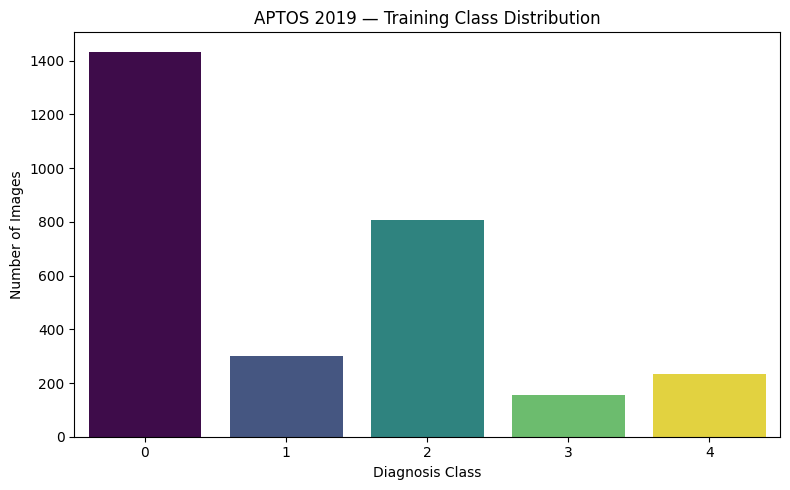

In [5]:
CLASS_NAMES = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

class_counts = train_df["diagnosis"].value_counts().sort_index()

print("Training class distribution:")
for cls_idx, count in class_counts.items():
    print(f"  {cls_idx} ({CLASS_NAMES[cls_idx]:<17}): {count:5d} images "
          f"({100 * count / len(train_df):.2f}%)")

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index,
            palette="viridis", legend=False)
plt.xlabel("Diagnosis Class")
plt.ylabel("Number of Images")
plt.title("APTOS 2019 — Training Class Distribution")
plt.tight_layout()
plt.show()

In [6]:
# 5. Image Preprocessing & Augmentation

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

valid_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transform:\n", train_transform)
print("\nValid transform:\n", valid_transform)


Train transform:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Valid transform:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [7]:
# 6. Custom Dataset Class

class APTOSDataset(Dataset):
    """PyTorch Dataset wrapper for the APTOS 2019 Blindness Detection data."""

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.loc[idx]
        img_path = row["file_path"]
        label = int(row["diagnosis"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = APTOSDataset(train_df, transform=train_transform)
valid_dataset = APTOSDataset(valid_df, transform=valid_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Valid dataset size: {len(valid_dataset)}")

sample_image, sample_label = train_dataset[0]
print(f"Sample image shape: {sample_image.shape} | label: {sample_label}")


Train dataset size: 2930
Valid dataset size: 366
Sample image shape: torch.Size([3, 224, 224]) | label: 2


In [8]:
# 7. DataLoaders

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"Train batches: {len(train_loader)} | Valid batches: {len(valid_loader)}")

images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape} | Batch label shape: {labels.shape}")


Train batches: 91 | Valid batches: 12
Batch image shape: torch.Size([32, 3, 224, 224]) | Batch label shape: torch.Size([32])


In [9]:
# 8. Swin Transformer Model

NUM_CLASSES = 5

swin_model = timm.create_model(
    "swin_base_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES,
).to(device)

total_params = sum(p.numel() for p in swin_model.parameters())
trainable_params = sum(p.numel() for p in swin_model.parameters() if p.requires_grad)

print(f"Model               : swin_base_patch4_window7_224")
print(f"Total Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# Quick forward-pass sanity check
sample_images, _ = next(iter(train_loader))
with torch.no_grad():
    sample_outputs = swin_model(sample_images.to(device))
print(f"Sample output shape : {sample_outputs.shape}")


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Model               : swin_base_patch4_window7_224
Total Parameters    : 86,748,349
Trainable Parameters: 86,748,349
Sample output shape : torch.Size([32, 5])


In [10]:
#  9. Loss, Optimizer & Scheduler

criterion = nn.CrossEntropyLoss()

LEARNING_RATE = 3e-5
WEIGHT_DECAY = 1e-4
EPOCHS = 15

optimizer = optim.AdamW(
    swin_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

BEST_MODEL_PATH = "best_swin_model.pth"

# Guardrail: confirm optimizer and model parameters are the same objects
optimizer_param_ids = {id(p) for group in optimizer.param_groups for p in group["params"]}
model_param_ids = {id(p) for p in swin_model.parameters()}
assert optimizer_param_ids == model_param_ids, "Optimizer is not bound to swin_model's parameters!"

print("Loss Function :", criterion)
print("Optimizer     : AdamW")
print("Scheduler     : CosineAnnealingLR")
print("Epochs        :", EPOCHS)
print("Checkpoint    :", BEST_MODEL_PATH)
print("Optimizer <-> model parameter check passed.")


Loss Function : CrossEntropyLoss()
Optimizer     : AdamW
Scheduler     : CosineAnnealingLR
Epochs        : 15
Checkpoint    : best_swin_model.pth
Optimizer <-> model parameter check passed.


In [11]:
# 10. Training & Validation Functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(loss=loss.item(), acc=100 * correct / total)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds


print("train_one_epoch and validate functions defined.")


train_one_epoch and validate functions defined.


In [12]:
# 11. Training Loop

best_accuracy = 0.0

train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(swin_model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc, y_true, y_pred = validate(swin_model, valid_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Valid Loss : {valid_loss:.4f}")
    print(f"Valid Acc  : {valid_acc:.4f}")

    if valid_acc > best_accuracy:
        best_accuracy = valid_acc
        torch.save(swin_model.state_dict(), BEST_MODEL_PATH)
        print("Best Swin model saved!")

print("\nSwin Transformer Training Complete!")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")



Epoch 1/15
----------------------------------------


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Train Loss : 0.7093
Train Acc  : 0.7342
Valid Loss : 0.5203
Valid Acc  : 0.8005
Best Swin model saved!

Epoch 2/15
----------------------------------------


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Train Loss : 0.4813
Train Acc  : 0.8201
Valid Loss : 0.5171
Valid Acc  : 0.8060
Best Swin model saved!

Epoch 3/15
----------------------------------------


...

Train Loss : 0.1499
Train Acc  : 0.9427
Valid Loss : 0.4940
Valid Acc  : 0.8497

Epoch 14/15
----------------------------------------


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Train Loss : 0.1463
Train Acc  : 0.9481
Valid Loss : 0.5088
Valid Acc  : 0.8470

Epoch 15/15
----------------------------------------


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Train Loss : 0.1488
Train Acc  : 0.9505
Valid Loss : 0.5046
Valid Acc  : 0.8525

Swin Transformer Training Complete!
Best Validation Accuracy: 0.8579


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

VALIDATION SET — EVALUATION SUMMARY (Swin Transformer)
Accuracy               : 0.8579
Precision (weighted)   : 0.8567
Recall (weighted)      : 0.8579
F1-Score (weighted)    : 0.8562
Quadratic Weighted Kappa (QWK): 0.9127

Classification Report:

                  precision    recall  f1-score   support

           No DR       0.98      0.99      0.99       172
            Mild       0.69      0.62      0.66        40
        Moderate       0.79      0.82      0.80       104
          Severe       0.76      0.59      0.67        22
Proliferative DR       0.65      0.71      0.68        28

        accuracy                           0.86       366
       macro avg       0.77      0.75      0.76       366
    weighted avg       0.86      0.86      0.86       366



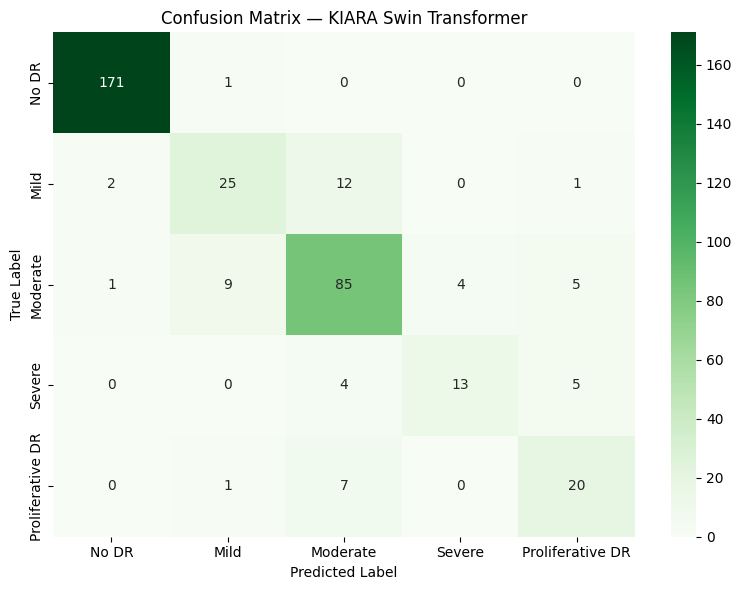

In [13]:
# 12. Comprehensive Evaluation

swin_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
swin_model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(valid_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = swin_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

print("=" * 55)
print("VALIDATION SET — EVALUATION SUMMARY (Swin Transformer)")
print("=" * 55)
print(f"Accuracy               : {acc:.4f}")
print(f"Precision (weighted)   : {precision:.4f}")
print(f"Recall (weighted)      : {recall:.4f}")
print(f"F1-Score (weighted)    : {f1:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")
print("=" * 55)

print("\nClassification Report:\n")
print(classification_report(
    all_labels, all_preds,
    target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    zero_division=0,
))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — KIARA Swin Transformer")
plt.tight_layout()
plt.show()


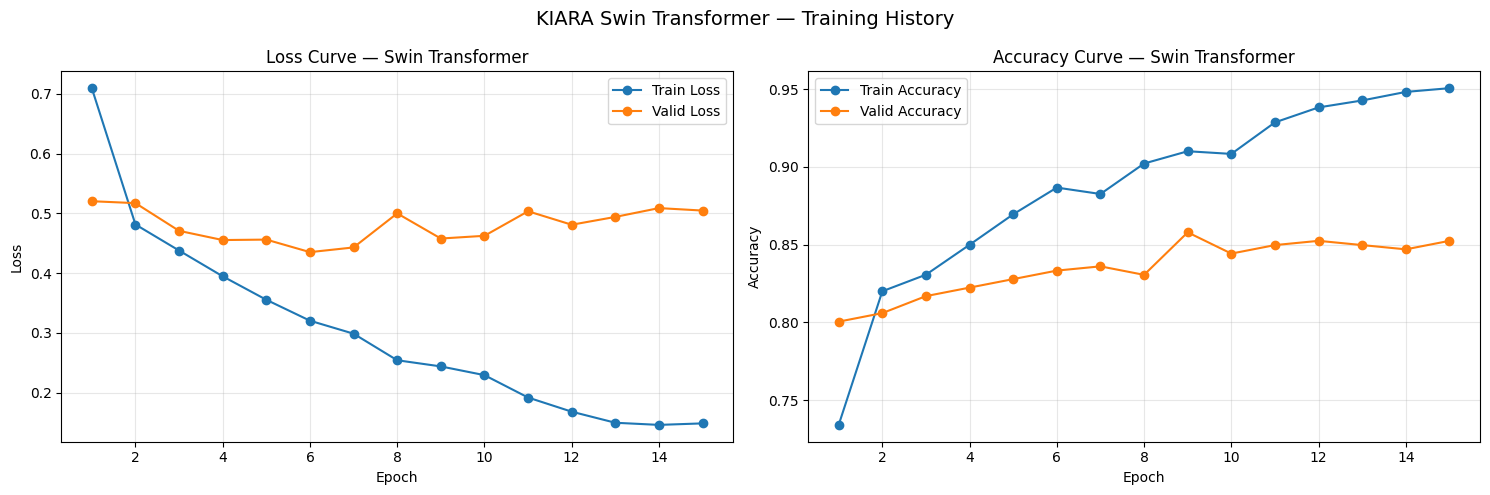

In [14]:
# # 13. Training Curves

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label="Train Loss", marker="o")
axes[0].plot(epochs_range, valid_losses, label="Valid Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve — Swin Transformer")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_accuracies, label="Train Accuracy", marker="o")
axes[1].plot(epochs_range, valid_accuracies, label="Valid Accuracy", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve — Swin Transformer")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("KIARA Swin Transformer — Training History", fontsize=14)
plt.tight_layout()
plt.show()


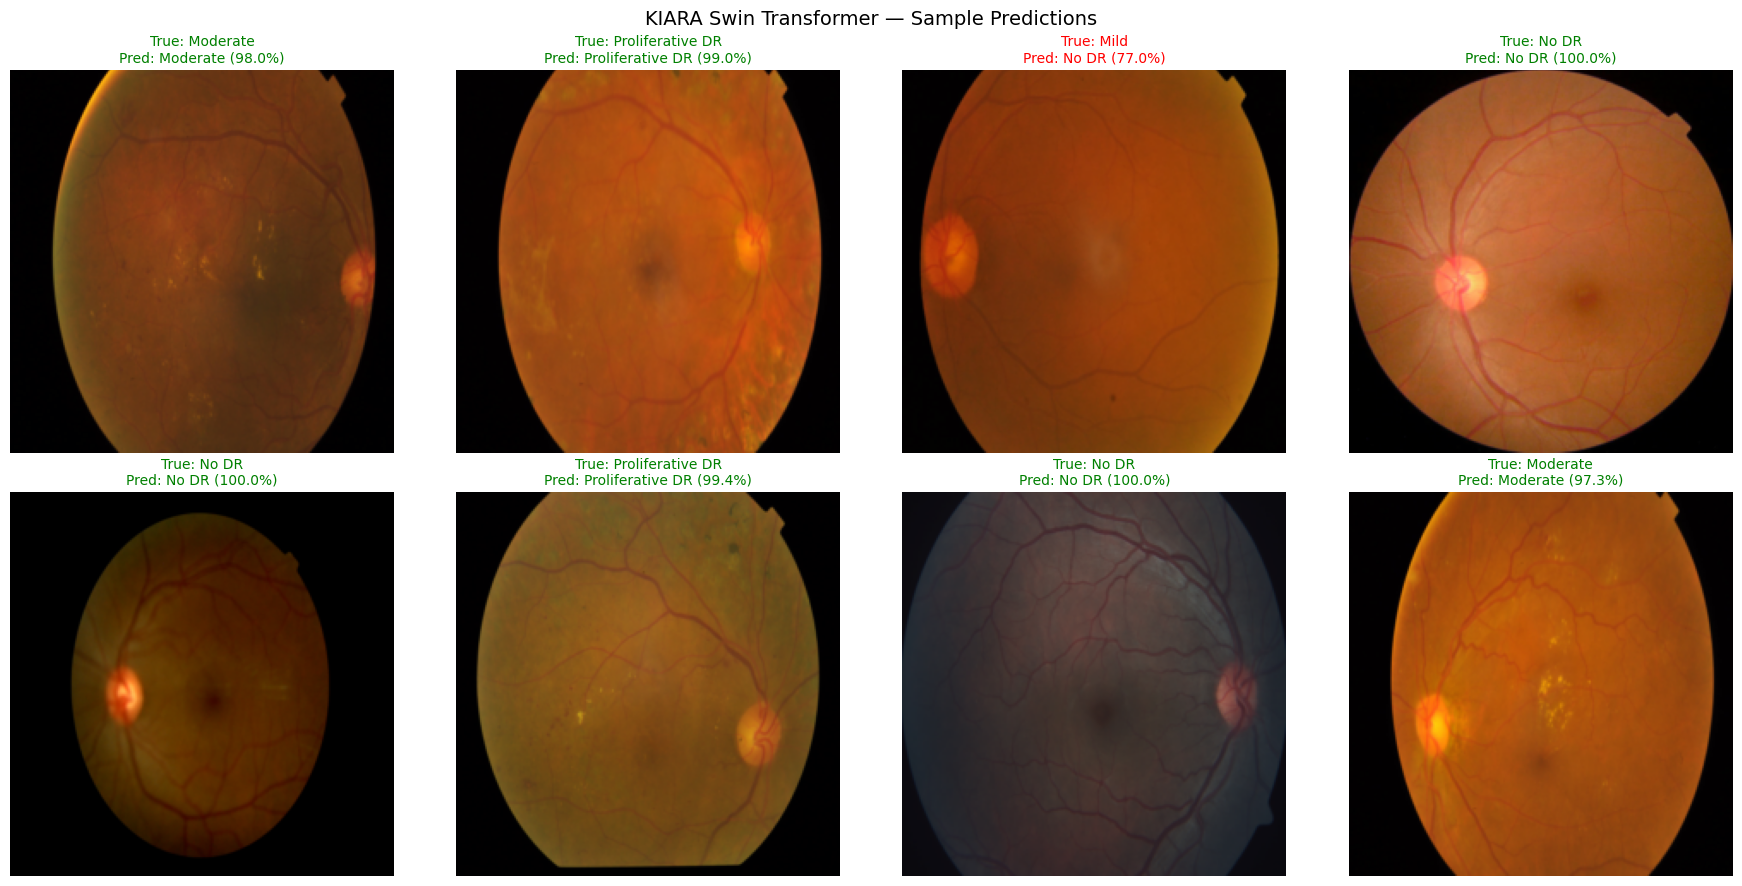

In [15]:
# 14. Prediction Visualization

def denormalize(tensor_img, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = tensor_img.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)


vis_images, vis_labels = next(iter(valid_loader))
vis_images_device = vis_images.to(device)

swin_model.eval()
with torch.no_grad():
    outputs = swin_model(vis_images_device)
    probs = torch.softmax(outputs, dim=1)
    confidences, preds = torch.max(probs, dim=1)

n_display = min(8, len(vis_images))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i in range(n_display):
    img = denormalize(vis_images[i])
    true_label = vis_labels[i].item()
    pred_label = preds[i].item()
    confidence = confidences[i].item()

    color = "green" if true_label == pred_label else "red"

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({confidence*100:.1f}%)",
        color=color, fontsize=10,
    )

plt.suptitle("KIARA Swin Transformer — Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()


In [16]:
# 15. Final model
FINAL_MODEL_PATH = "kiara_swin_final.pth"

torch.save(swin_model.state_dict(), FINAL_MODEL_PATH)

torch.save({
    "model_state_dict": swin_model.state_dict(),
    "model_name": "swin_base_patch4_window7_224",
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "best_val_accuracy": float(best_accuracy),
    "qwk": float(qwk),
}, "kiara_swin_checkpoint.pth")

print(f"Final model weights saved to : {FINAL_MODEL_PATH}")
print("Rich checkpoint saved to      : kiara_swin_checkpoint.pth")


Final model weights saved to : kiara_swin_final.pth
Rich checkpoint saved to      : kiara_swin_checkpoint.pth


In [17]:
# 16. Standalone Inference Function

def predict_image(image_path: str, model=swin_model, transform=valid_transform, device=device):
    """Run inference on a single retinal fundus image."""
    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1).squeeze(0)
        confidence, predicted_class = torch.max(probs, dim=0)

    class_probabilities = {CLASS_NAMES[i]: float(probs[i].item()) for i in range(NUM_CLASSES)}

    return {
        "predicted_class": int(predicted_class.item()),
        "predicted_label": CLASS_NAMES[int(predicted_class.item())],
        "confidence": float(confidence.item()),
        "class_probabilities": class_probabilities,
    }


example_path = valid_df.iloc[0]["file_path"]
example_true_label = CLASS_NAMES[int(valid_df.iloc[0]["diagnosis"])]

result = predict_image(example_path)

print(f"Image           : {example_path}")
print(f"Ground truth    : {example_true_label}")
print(f"Predicted class : {result['predicted_label']}")
print(f"Confidence      : {result['confidence']*100:.2f}%")
print("\nFull class probability distribution:")
for cls_name, prob in result["class_probabilities"].items():
    print(f"  {cls_name:<18}: {prob*100:.2f}%")



Image           : /kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/000c1434d8d7.png
Ground truth    : Moderate
Predicted class : Moderate
Confidence      : 98.03%

Full class probability distribution:
  No DR             : 0.00%
  Mild              : 0.23%
  Moderate          : 98.03%
  Severe            : 0.87%
  Proliferative DR  : 0.86%
